This is for creating histograms of detected fish and schools versus depth.

Y-axis is the amount of fish and schools detected, X-axis is depth intervals.
To eliminate empty depth intervals, all depths before the first detection has been removed. 

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [25]:
INPUT_PATHS = [
    r"C:\Users\tilde\Documents\LSSS\fish_school_events (1).csv",
    r"C:\Users\tilde\Documents\LSSS\fish_school_events (2).csv",
    r"C:\Users\tilde\Documents\LSSS\fish_school_events_0612.csv",
]

CUSTOM_CATEGORY_NAMES = {
    'individual_fish': 'Individual fish',
    'school': 'School of fish',
}

COLORS = {
    'Individual fish': (0.20, 0.45, 0.85),
    'School of fish': (0.75, 0.10, 0.10),
}

BIN_WIDTH_M = 1.0

In [26]:
dfs = []
for path in INPUT_PATHS:
    df = pd.read_csv(path)
    df["source_file"] = path
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

data["depth_m"] = (data["depth_min_m"] + data["depth_max_m"]) / 2 #I chose to use midpoint depth! You can change this to min or max if you prefer.

data['category'] = data['category'].map(CUSTOM_CATEGORY_NAMES).fillna(data['category'])

print(f"Loaded {len(data)} total events from {len(INPUT_PATHS)} files")
print(data["category"] .value_counts())
data.head()

Loaded 277 total events from 3 files
category
Individual fish    220
School of fish      57
Name: count, dtype: int64


,category,start_time,end_time,duration_s,lat,lon,depth_min_m,depth_max_m,sv_sum,sv_max,sv_max_db,n_hits,source_file,depth_m
0,Individual fish,2026-06-10 07:07:49,2026-06-10 07:07:50,2,55.757323,12.732483,9.8,10.2,239.2902,212.6582,23.276821,3,C:\Users\tilde\Documents\LSSS\fish_school_even...,10.0
1,Individual fish,2026-06-10 07:08:10,2026-06-10 07:08:11,2,55.757740,12.733475,9.2,9.8,269.2308,116.5973,20.666885,4,C:\Users\tilde\Documents\LSSS\fish_school_even...,9.5
2,School of fish,2026-06-10 07:08:16,2026-06-10 07:08:18,3,55.757881,12.733757,8.8,9.8,1921.1023,809.6875,29.083174,8,C:\Users\tilde\Documents\LSSS\fish_school_even...,9.3
3,Individual fish,2026-06-10 07:08:23,2026-06-10 07:08:25,3,55.758000,12.734074,9.2,9.8,299.1608,215.9901,23.344338,5,C:\Users\tilde\Documents\LSSS\fish_school_even...,9.5
4,Individual fish,2026-06-10 07:08:52,2026-06-10 07:08:53,2,55.758305,12.735035,9.8,10.2,162.3926,83.4703,19.215320,4,C:\Users\tilde\Documents\LSSS\fish_school_even...,10.0


In [27]:
min_depth = data["depth_m"].min()
max_depth = data["depth_m"].max()

bin_start = np.floor(min_depth / BIN_WIDTH_M) * BIN_WIDTH_M 
bin_end = np.ceil(max_depth / BIN_WIDTH_M) * BIN_WIDTH_M

bins = np.arange(bin_start, bin_end + BIN_WIDTH_M, BIN_WIDTH_M)

print(f"First detection depth: {min_depth:.2f} m")
print(f"Last detection depth:  {max_depth:.2f} m")
print(f"Histogram bins start at {bin_start} m (instead of surface), end at {bin_end} m")

First detection depth: 5.00 m
Last detection depth:  12.50 m
Histogram bins start at 5.0 m (instead of surface), end at 13.0 m


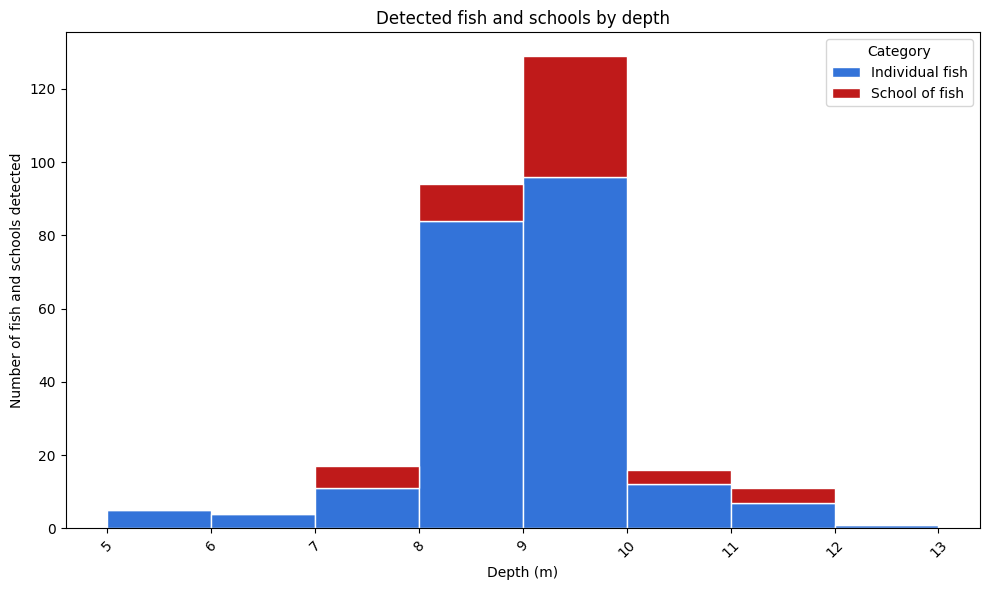

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

categories = data["category"].unique()
depth_by_category = [data.loc[data["category"] == c, "depth_m"] for c in categories]


colors = [COLORS[c] for c in categories]

ax.hist(
    depth_by_category,
    bins=bins,
    stacked=True,
    label=categories,
    color=colors,
    edgecolor="white",
)

ax.set_xlabel("Depth (m)")
ax.set_ylabel("Number of fish and schools detected")
ax.set_title("Detected fish and schools by depth")
ax.legend(title="Category")
ax.set_xticks(bins)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()